In [ ]:
#imports
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

import sys 
import os
sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../data"))

import data_splitting as data
import preprocessing as prep
import metrics as mtr
import utils as utls
import models as mdls

#pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Desarrollo de Redes Neuronales para deteccion de letras y digitos manuscritos
(pensar otro titulo relacionado)

### 1. Analisis y Preprocesamiento de Datos

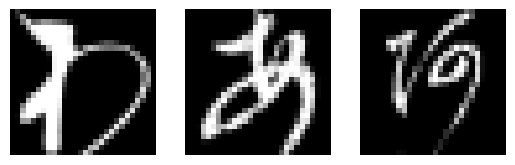

In [33]:
Ximg, Yimg = prep.load_img("../data/raw/X_images.npy","../data/raw/Y_images.npy")

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(Ximg[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()


In [53]:
#division del dataset y normalizacion
print(Ximg.shape)
Xtrain, Ytrain, Xval, Yval, Xtest, Ytest = data.initial_split(Ximg, Yimg)

Xtrain, Xval, Xtest = prep.normalization(Xtrain, Xval, Xtest)
print(Xtrain.shape)


(5000, 784)
(3500, 784)


### 2. Implementacion y Entrenamiento de una Red Neuronal Basica

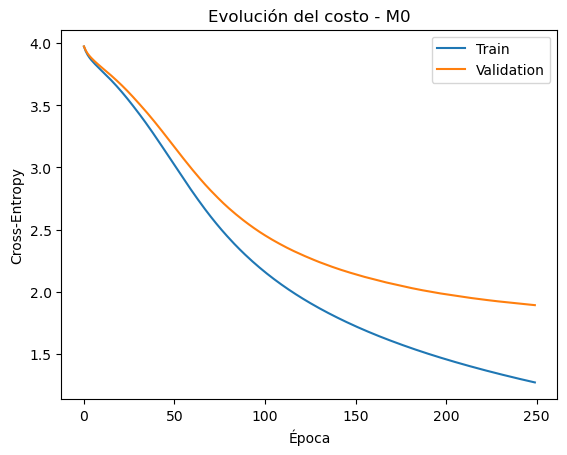

In [35]:
m0 = mdls.MLP([784, 128, 64, 49])

start = time.time()
train_costs_m0, val_costs_m0 = m0.fit(Xtrain, Ytrain, Xval, Yval, 250, 0.1)
end = time.time() - start

plt.plot(train_costs_m0, label='Train')
plt.plot(val_costs_m0, label='Validation')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy')
plt.title('Evolución del costo - M0')
plt.legend()
plt.show()

In [36]:
pred = m0.predict(Xval)

acc0 = mtr.accuracy(m0, Ytrain)
ce_0 = mtr.cross_entropy_eval(m0, Xtrain, Ytrain)
cm_0 = mtr.confusion_matrix(m0, Xtrain, Ytrain)
f1_0 = mtr.f1_macro(m0, Xtrain, Ytrain)

print(acc0, ce_0, cm_0, f1_0)


0.0 1.2688626716939406 [[43  2  0 ...  0  0  0]
 [ 0 68  0 ...  0  0  0]
 [ 0  0 85 ...  0  0  0]
 ...
 [ 0  1  1 ... 64  0  0]
 [ 0  0  0 ...  0 66  0]
 [ 0  0  0 ...  0  0 25]] 0.688679370845835


### 2. Implementación y Entrenamiento de una Red Neuronal Avanzada

In [ ]:
#Lineal
model_lr = mdls.MLP([784, 128, 64, 49])

start = time.time()
train_costs_lr, val_costs_lr =model_lr.fit(Xtrain, Ytrain, Xval, Yval,
             lr=0.1, epochs=250, lr_schedule="linear")
end2 = time.time() - start

#Exponencial
model_exp = mdls.MLP([784, 128, 64, 49])

start = time.time()
train_costs_exp, val_costs_exp = model_exp.fit(Xtrain, Ytrain, Xval, Yval,
             lr=0.1, epochs=250, lr_schedule="exponential")
end3 = time.time() - start

# Mini-batch
model_mb = mdls.MLP([784, 128, 64, 49])
start = time.time()
train_costs_mb, val_costs_mb = model_mb.fit(Xtrain, Ytrain, Xval, Yval,
             lr=0.01, epochs=100, optimizer="sgd", batch_size=64)
end4 = time.time() - start




In [47]:
# Adam
model_adam = mdls.MLP([784, 128, 64, 49])
start = time.time()
train_costs_adam, val_costs_adam = model_adam.fit(Xtrain, Ytrain, Xval, Yval,
               lr=0.0001, epochs=50, optimizer="adam", l2_lambda=1e-3, batch_size=64)
end5 = time.time() - start



In [45]:
# Regularizacion L2
model_l2 = mdls.MLP([784, 128, 64, 49])
start = time.time()
train_costs_l2, val_costs_l2 = model_l2.fit(Xtrain, Ytrain, Xval, Yval, lr=0.1, epochs=250, l2_lambda=1e-4)
end6 = time.time() - start

start = time.time()
model_es = mdls.MLP([784, 128, 64, 49])
train_costs_es, val_costs_es = model_es.fit(
    Xtrain, Ytrain, Xval, Yval,
    lr=0.1, epochs=250,   
    early_stopping=True,
    patience=15
)
end7 = time.time() - start


In [48]:
resultados = {
    "M0 (Base)":  {"Tiempo (s)": round(end, 2), "Train CE": round(train_costs_m0[-1], 4),   "Val CE": round(val_costs_m0[-1], 4),   "Train Acc": round(mtr.accuracy(m0.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(m0.predict(Xval), Yval), 4)},
    "LR Lineal":  {"Tiempo (s)": round(end2, 2), "Train CE": round(train_costs_lr[-1], 4),   "Val CE": round(val_costs_lr[-1], 4),   "Train Acc": round(mtr.accuracy(model_lr.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(model_lr.predict(Xval), Yval), 4)},
    "LR Exponencial": {"Tiempo (s)": round(end3, 2), "Train CE": round(train_costs_exp[-1], 4),  "Val CE": round(val_costs_exp[-1], 4),  "Train Acc": round(mtr.accuracy(model_exp.predict(Xtrain), Ytrain), 4),  "Val Acc": round(mtr.accuracy(model_exp.predict(Xval), Yval), 4)},
    "Mini-batch SGD": {"Tiempo (s)": round(end4, 2), "Train CE": round(train_costs_mb[-1], 4),   "Val CE": round(val_costs_mb[-1], 4),   "Train Acc": round(mtr.accuracy(model_mb.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(model_mb.predict(Xval), Yval), 4)},
    "Adam":    {"Tiempo (s)": round(end5, 2), "Train CE": round(train_costs_adam[-1], 4), "Val CE": round(val_costs_adam[-1], 4), "Train Acc": round(mtr.accuracy(model_adam.predict(Xtrain), Ytrain), 4), "Val Acc": round(mtr.accuracy(model_adam.predict(Xval), Yval), 4)},
    "L2":  {"Tiempo (s)": round(end6, 2), "Train CE": round(train_costs_l2[-1], 4),   "Val CE": round(val_costs_l2[-1], 4),   "Train Acc": round(mtr.accuracy(model_l2.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(model_l2.predict(Xval), Yval), 4)},
    "Early Stopping": {"Tiempo (s)": round(end7, 2), "Train CE": round(train_costs_es[-1], 4),   "Val CE": round(val_costs_es[-1], 4),   "Train Acc": round(mtr.accuracy(model_es.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(model_es.predict(Xval), Yval), 4)},

}

df = pd.DataFrame(resultados).T
df.index.name = "Modelo"
df

,Tiempo (s),Train CE,Val CE,Train Acc,Val Acc
Modelo,,,,,
M0 (Base),41.95,1.2689,1.8911,0.6929,0.5173
LR Lineal,33.74,1.8240,2.2034,0.5697,0.4547
LR Exponencial,31.88,1.3042,1.9444,0.6857,0.5133
Mini-batch SGD,20.03,0.6094,1.7642,0.8726,0.5853
Adam,13.67,0.8451,1.7174,0.8226,0.5733
L2,36.36,1.1947,1.8196,0.7011,0.5253
Early Stopping,33.74,1.2112,1.9165,0.7054,0.5227


Se busca la mejor configuracion para cada una de las mejores, variando entre cantidad de capas e hiperparametros

In [57]:
configuraciones = [
    {"hidden": [256, 128],      "lr": 0.001,  "bs": 64,  "l2": 1e-4},
    {"hidden": [256, 128],      "lr": 0.001,  "bs": 64,  "l2": 1e-3},
    {"hidden": [512, 256, 128], "lr": 0.001,  "bs": 64,  "l2": 1e-4},
    {"hidden": [256, 128, 64],  "lr": 0.0001, "bs": 32,  "l2": 1e-4},
    {"hidden": [512, 256],      "lr": 0.001,  "bs": 128, "l2": 1e-3},
]

resultados_m1 = []

for config in configuraciones:
    layer_sizes = [784] + config["hidden"] + [49]
    model = mdls.MLP(layer_sizes)
    
    start = time.time()
    train_costs, val_costs = model.fit(
        Xtrain, Ytrain, Xval, Yval,
        lr=config["lr"],
        epochs=50,
        optimizer="adam",
        batch_size=config["bs"],
        l2_lambda=config["l2"],
        early_stopping=True,
        patience=15
    )
    elapsed = time.time() - start
    
    val_acc = mtr.accuracy(model.predict(Xval), Yval)
    val_ce  = val_costs[-1]
    
    resultados_m1.append({
        "Arquitectura": str(layer_sizes),
        "lr": config["lr"],
        "batch_size": config["bs"],
        "l2_lambda": config["l2"],
        "Tiempo (s)": round(elapsed, 2),
        "Val CE": round(val_ce, 4),
        "Val Acc": round(val_acc, 4),
        "model": model
    })
    print(f"✓ {layer_sizes} | Val Acc: {val_acc:.4f}")

# Tabla resumen
df_m1 = pd.DataFrame(resultados_m1).drop(columns="model")
df_m1 = df_m1.sort_values("Val Acc", ascending=False)
display(df_m1)

# Mejor modelo
mejor = max(resultados_m1, key=lambda x: x["Val Acc"])
m1 = mejor["model"]
print(f"\nMejor configuración: {mejor['Arquitectura']}")
print(f"Val Acc: {mejor['Val Acc']}")

✓ [784, 256, 128, 49] | Val Acc: 0.6147
✓ [784, 256, 128, 49] | Val Acc: 0.6640
✓ [784, 512, 256, 128, 49] | Val Acc: 0.6320
✓ [784, 256, 128, 64, 49] | Val Acc: 0.6213
✓ [784, 512, 256, 49] | Val Acc: 0.6547


,Arquitectura,lr,batch_size,l2_lambda,Tiempo (s),Val CE,Val Acc
1,"[784, 256, 128, 49]",0.0010,64,0.0010,29.31,1.5182,0.6640
4,"[784, 512, 256, 49]",0.0010,128,0.0010,32.97,1.4523,0.6547
2,"[784, 512, 256, 128, 49]",0.0010,64,0.0001,45.66,1.8509,0.6320
3,"[784, 256, 128, 64, 49]",0.0001,32,0.0001,83.33,1.7756,0.6213
0,"[784, 256, 128, 49]",0.0010,64,0.0001,18.44,1.8048,0.6147



Mejor configuración: [784, 256, 128, 49]
Val Acc: 0.664


### 4. Desarrollo de una Red Neuronal con Pytorch

In [62]:
LAYER_SIZES  = [784, 256, 128, 49]
LR  = 1e-3
BATCH_SIZE = 128
L2_LAMBDA  = 1e-3
EPOCHS = 50       

def to_tensor(X, y):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_t, y_t)

train_loader = DataLoader(to_tensor(Xtrain, Ytrain),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(to_tensor(Xval,   Yval),
                          batch_size=512, shuffle=False)
test_loader  = DataLoader(to_tensor(Xtest,  Ytest),
                          batch_size=512, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# M2: misma arquitectura e hiperparámetros que M1
m2 = mdls.MLP_PyTorch(LAYER_SIZES).to(device)
m2, history_m2 = mdls.train_pytorch_model(
    m2, train_loader, val_loader, device,
    lr=LR, l2_lambda=L2_LAMBDA, epochs=EPOCHS, patience=15
)

Epoch   5 | Train Loss: 1.4087  Acc: 0.6437 | Val Loss: 1.9060  Acc: 0.5147
Epoch  10 | Train Loss: 0.9048  Acc: 0.7840 | Val Loss: 1.6531  Acc: 0.5947
Epoch  15 | Train Loss: 0.5936  Acc: 0.8714 | Val Loss: 1.6297  Acc: 0.6053
Epoch  20 | Train Loss: 0.3931  Acc: 0.9283 | Val Loss: 1.6696  Acc: 0.6267
Epoch  25 | Train Loss: 0.2625  Acc: 0.9600 | Val Loss: 1.7009  Acc: 0.6147
Epoch  30 | Train Loss: 0.1697  Acc: 0.9840 | Val Loss: 1.7388  Acc: 0.6213
Early stopping en época 30


Muestra overfitting

In [63]:
configuraciones_m3 = [
    # Baseline (igual a M2, para comparar)
    {"hidden": [512, 256],      "activation": "relu",      "dropout": 0.0,  "lr": 1e-3, "l2": 1e-3},
    # Variar activación
    {"hidden": [512, 256],      "activation": "leakyrelu", "dropout": 0.0,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [512, 256],      "activation": "gelu",      "dropout": 0.0,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [512, 256],      "activation": "silu",      "dropout": 0.0,  "lr": 1e-3, "l2": 1e-3},
    # Agregar Dropout
    {"hidden": [512, 256],      "activation": "gelu",      "dropout": 0.2,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [512, 256],      "activation": "gelu",      "dropout": 0.4,  "lr": 1e-3, "l2": 1e-3},
    # Variar arquitectura con la mejor activación
    {"hidden": [512, 256, 128], "activation": "gelu",      "dropout": 0.3,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [1024, 512],     "activation": "gelu",      "dropout": 0.3,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [1024, 512, 256],"activation": "gelu",      "dropout": 0.3,  "lr": 1e-3, "l2": 1e-3},
]

def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = make_loader(Xtrain, Ytrain, batch_size=128, shuffle=True)
val_loader   = make_loader(Xval,   Yval,   batch_size=512, shuffle=False)
test_loader  = make_loader(Xtest,  Ytest,  batch_size=512, shuffle=False)

In [ ]:
resultados_m3 = []

for config in configuraciones_m3:
    layer_sizes = [784] + config["hidden"] + [49]
    start = time.time()
    
    model = mdls.MLP_M3(layer_sizes, config["activation"], config["dropout"]).to(device)
    model, history = mdls.train_pytorch_model(  
        model, train_loader, val_loader, device,
        lr=config["lr"],
        l2_lambda=config["l2"],
        epochs=60,
        patience=10
    )                                           
    
    val_loss = min(history["val_loss"])
    val_acc  = max(history["val_acc"])
    elapsed  = time.time() - start
        
    resultados_m3.append({
        "Arquitectura":  str(layer_sizes),
        "Activación":    config["activation"],
        "Dropout":       config["dropout"],
        "lr":            config["lr"],
        "l2":            config["l2"],
        "Tiempo (s)":    round(elapsed, 2),
        "Val CE":        round(val_loss, 4),
        "Val Acc":       round(val_acc,  4),
        "model":         model,
    })

df_m3 = pd.DataFrame(resultados_m3).drop(columns="model")
df_m3 = df_m3.sort_values("Val Acc", ascending=False)
display(df_m3)

mejor_m3 = max(resultados_m3, key=lambda x: x["Val Acc"])
m3 = mejor_m3["model"]
print(f"\nMejor M3: {mejor_m3['Arquitectura']}")
print(f"Activación: {mejor_m3['Activación']} | Dropout: {mejor_m3['Dropout']}")
print(f"Val Acc: {mejor_m3['Val Acc']}")

Early stopping en época 22
Early stopping en época 19
Early stopping en época 26
Early stopping en época 21
Early stopping en época 27
Early stopping en época 37
Early stopping en época 33
Early stopping en época 28
Early stopping en época 22


,Arquitectura,Activación,Dropout,lr,l2,Tiempo (s),Val CE,Val Acc
8,"[784, 1024, 512, 256, 49]",gelu,0.3,0.001,0.001,15.60,1.3237,0.7093
7,"[784, 1024, 512, 49]",gelu,0.3,0.001,0.001,18.06,1.3359,0.7053
5,"[784, 512, 256, 49]",gelu,0.4,0.001,0.001,13.66,1.2918,0.7040
4,"[784, 512, 256, 49]",gelu,0.2,0.001,0.001,9.84,1.3880,0.6880
6,"[784, 512, 256, 128, 49]",gelu,0.3,0.001,0.001,13.09,1.3445,0.6733
2,"[784, 512, 256, 49]",gelu,0.0,0.001,0.001,8.31,1.5742,0.6613
3,"[784, 512, 256, 49]",silu,0.0,0.001,0.001,6.68,1.5886,0.6573
0,"[784, 512, 256, 49]",relu,0.0,0.001,0.001,7.46,1.5642,0.6520
1,"[784, 512, 256, 49]",leakyrelu,0.0,0.001,0.001,5.73,1.5393,0.6440



Mejor M3: [784, 1024, 512, 256, 49]
Activación: gelu | Dropout: 0.3
Val Acc: 0.7093


In [71]:
r_m0 = mtr.evaluate_numpy_model(m0, Xtest, Ytest)
r_m1 = mtr.evaluate_numpy_model(m1, Xtest, Ytest)
r_m2 = mtr.evaluate_torch_model(m2, test_loader, device)
r_m3 = mtr.evaluate_torch_model(m3, test_loader, device)

# ── Tabla resumen ─────────────────────────────────────────────────────────────
df_comp = pd.DataFrame({
    "Modelo":   ["M0 (base propio)", "M1 (mejor propio)",
                 "M2 (PyTorch=M1)",  "M3 (mejor PyTorch)"],
    "Test Acc": [r_m0["acc"], r_m1["acc"], r_m2["acc"], r_m3["acc"]],
    "Test CE":  [r_m0["ce"],  r_m1["ce"],  r_m2["ce"],  r_m3["ce"]],
    "F1 Macro": [r_m0["f1"],  r_m1["f1"],  r_m2["f1"],  r_m3["f1"]],
}).round(4)
display(df_comp)


,Modelo,Test Acc,Test CE,F1 Macro
0,M0 (base propio),0.5453,1.8232,0.5376
1,M1 (mejor propio),0.6427,1.4393,0.6421
2,M2 (PyTorch=M1),0.6187,1.5119,0.6133
3,M3 (mejor PyTorch),0.6653,1.2748,0.6606


In [72]:
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

resultados_ruido = {
    "M0": [], "M1": [], "M2": [], "M3": []
}

for noise in noise_levels:
    # Perturbar test set
    X_test_noisy = utls.add_gaussian_noise(Xtest, noise)
    
    # Armar loader para modelos torch
    test_loader_noisy = make_loader(X_test_noisy, Ytest, batch_size=512, shuffle=False)
    
    # Evaluar cada modelo
    r0 = mtr.evaluate_numpy_model(m0, X_test_noisy, Ytest)
    r1 = mtr.evaluate_numpy_model(m1, X_test_noisy, Ytest)
    r2 = mtr.evaluate_torch_model(m2, test_loader_noisy, device)
    r3 = mtr.evaluate_torch_model(m3, test_loader_noisy, device)
    
    resultados_ruido["M0"].append(r0["acc"])
    resultados_ruido["M1"].append(r1["acc"])
    resultados_ruido["M2"].append(r2["acc"])
    resultados_ruido["M3"].append(r3["acc"])
    
    print(f"Ruido {noise:.1f} | M0: {r0['acc']:.4f} | M1: {r1['acc']:.4f} "
          f"| M2: {r2['acc']:.4f} | M3: {r3['acc']:.4f}")

Ruido 0.0 | M0: 0.5453 | M1: 0.6427 | M2: 0.6187 | M3: 0.6653
Ruido 0.1 | M0: 0.5227 | M1: 0.6227 | M2: 0.5760 | M3: 0.6333
Ruido 0.2 | M0: 0.4880 | M1: 0.5587 | M2: 0.5173 | M3: 0.5867
Ruido 0.3 | M0: 0.4280 | M1: 0.4507 | M2: 0.4560 | M3: 0.4720
Ruido 0.5 | M0: 0.2627 | M1: 0.2813 | M2: 0.2680 | M3: 0.3093
Ruido 0.7 | M0: 0.1813 | M1: 0.1707 | M2: 0.1773 | M3: 0.1693
Ruido 1.0 | M0: 0.0987 | M1: 0.0773 | M2: 0.1053 | M3: 0.0960


,M0,M1,M2,M3
Noise Level,,,,
0.0,0.5453,0.6427,0.6187,0.6653
0.1,0.5227,0.6227,0.5760,0.6333
0.2,0.4880,0.5587,0.5173,0.5867
0.3,0.4280,0.4507,0.4560,0.4720
0.5,0.2627,0.2813,0.2680,0.3093
0.7,0.1813,0.1707,0.1773,0.1693
1.0,0.0987,0.0773,0.1053,0.0960


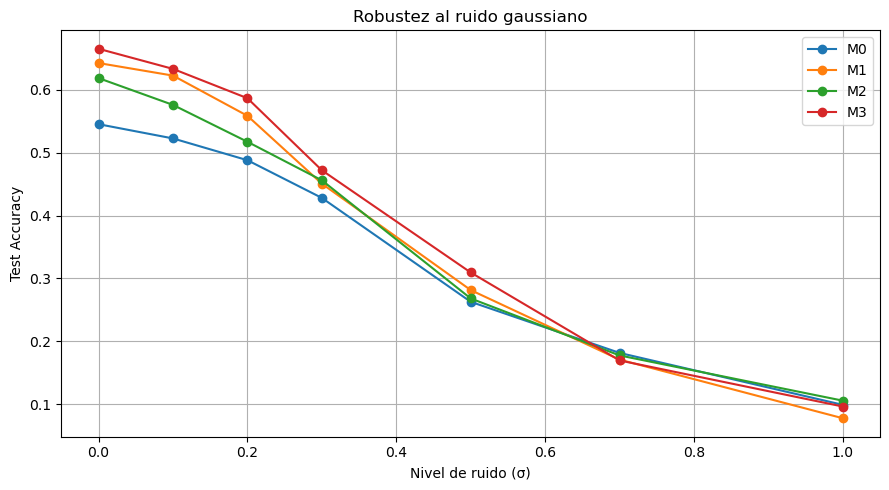

In [73]:
df_ruido = pd.DataFrame(resultados_ruido, index=noise_levels)
df_ruido.index.name = "Noise Level"
display(df_ruido.round(4))

# ── Gráfico ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
for modelo, accs in resultados_ruido.items():
    plt.plot(noise_levels, accs, marker="o", label=modelo)

plt.xlabel("Nivel de ruido (σ)")
plt.ylabel("Test Accuracy")
plt.title("Robustez al ruido gaussiano")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("robustez_ruido.png", dpi=150, bbox_inches="tight")
plt.show()